<a href="https://colab.research.google.com/github/Ms-Ulfiyahrustam/Prediction_Apple_Share/blob/main/Prediksi_Harga_Closing_Saham_Apple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Deskripsi**

Pada projek ini, kami melakukan analisis histori harga saham Apple berdasarkan rekam jejak transaksi saham harian dari perusahaan teknologi Apple Inc.

##**Tujuan**

Tujuan dari projek ini adalah mengetahui harga closing dari saham Apple Inc.

## **Library**
Pandas - Baca CSV atau dataset

Matplotlib.pyplot & Seaborn - Visualisasi saham

Numpy - Perhitungan untuk prediksi

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)




## Load data

In [20]:
df = pd.read_csv('Apple.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.745996,212818400
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,24.048864,257142000
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,24.051125,263188400
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,24.388372,160423600
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,25.325430,237458000


In [21]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [22]:
print("=== INFO DATASET ===")
print(df.info())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1761 non-null   datetime64[ns]
 1   Open       1761 non-null   float64       
 2   High       1761 non-null   float64       
 3   Low        1761 non-null   float64       
 4   Close      1761 non-null   float64       
 5   Adj Close  1761 non-null   float64       
 6   Volume     1761 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 96.4 KB
None


In [26]:
df.head(5 )

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.745996,212818400
1,2015-01-05,27.072500,27.162500,26.352501,26.562500,24.048864,257142000
2,2015-01-06,26.635000,26.857500,26.157499,26.565001,24.051125,263188400
3,2015-01-07,26.799999,27.049999,26.674999,26.937500,24.388372,160423600
4,2015-01-08,27.307501,28.037500,27.174999,27.972500,25.325430,237458000


In [27]:
print(f"\nRentang data: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total baris : {len(df)}")


Rentang data: 2015-01-02 → 2021-12-29
Total baris : 1761


## EDA

### Cleaning data


In [28]:
print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())


=== CEK MISSING VALUE ===
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [29]:
print("\n=== CEK DUPLIKAT ===")
print(f"Jumlah duplikat: {df.duplicated().sum()}")


=== CEK DUPLIKAT ===
Jumlah duplikat: 0


### explore data ->  with visualition

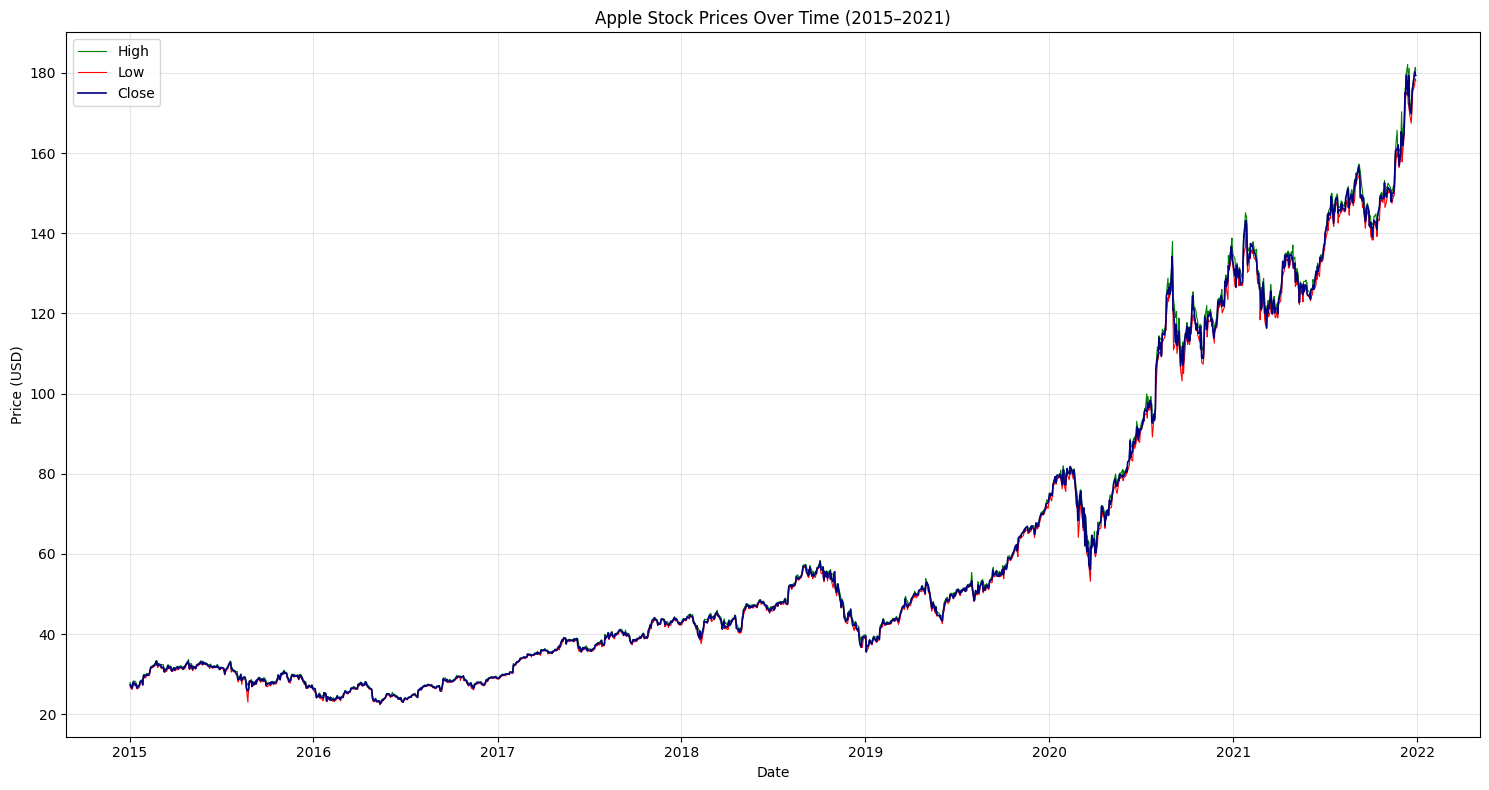

In [41]:
# Visualisasi harga historis
plt.figure(figsize=(15, 8))
plt.plot(df["Date"], df["High"],  label="High",  color="green",  linewidth=0.8)
plt.plot(df["Date"], df["Low"],   label="Low",   color="red",    linewidth=0.8)
plt.plot(df["Date"], df["Close"], label="Close", color="navy",   linewidth=1.2)
plt.title("Apple Stock Prices Over Time (2015–2021)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("01_harga_historis.png", dpi=150)
plt.show()

Heatmap korelasi (sebelum feature engineering)


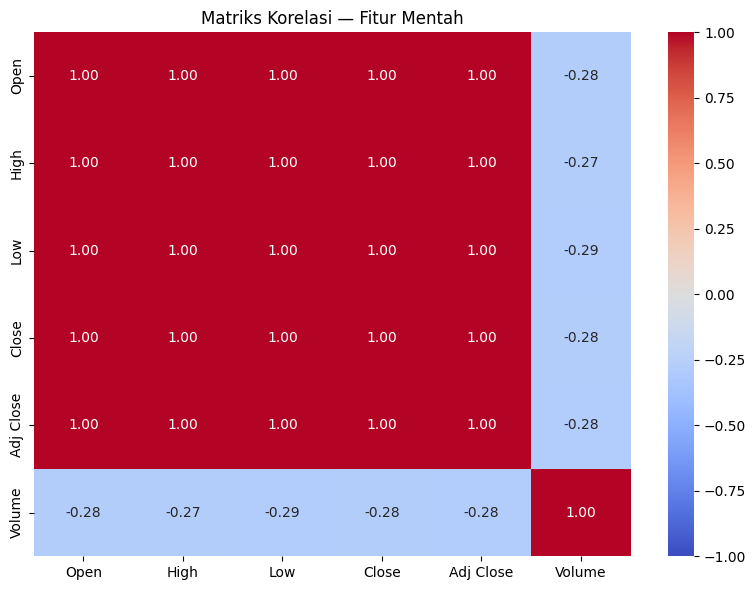

In [34]:
print("Heatmap korelasi (sebelum feature engineering)")
plt.figure(figsize=(8, 6))
numeric_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
)
plt.title("Matriks Korelasi — Fitur Mentah")
plt.tight_layout()
plt.savefig("02_korelasi_mentah.png", dpi=150)
plt.show()

## Feature Enginering

In [42]:
# --- Moving Average ---
df["MA_5"]  = df["Close"].rolling(window=5,  min_periods=1).mean()
df["MA_20"] = df["Close"].rolling(window=20, min_periods=1).mean()
df["MA_50"] = df["Close"].rolling(window=50, min_periods=1).mean()

In [43]:
# --- Price Spread & Candlestick Body ---
df["daily_range"]    = df["High"] - df["Low"]           # Volatilitas hari ini
df["body"]           = df["Close"] - df["Open"]         # Arah pergerakan
df["upper_shadow"]   = df["High"] - df[["Open","Close"]].max(axis=1)
df["lower_shadow"]   = df[["Open","Close"]].min(axis=1) - df["Low"]

In [44]:
# --- Momentum & Return ---
df["return_1d"] = df["Close"].pct_change(1)             # Return 1 hari
df["return_5d"] = df["Close"].pct_change(5)             # Return 5 hari
df["momentum"]  = df["Close"] - df["Close"].shift(10)   # Momentum 10 hari

In [45]:
# --- Volatilitas Rolling ---
df["volatility_10"] = df["Close"].rolling(10).std()
df["volatility_20"] = df["Close"].rolling(20).std()

In [46]:
# --- Volume Change ---
df["volume_change"] = df["Volume"].pct_change()
df["vol_MA_5"]      = df["Volume"].rolling(5).mean()

In [47]:
# --- Cyclical Encoding Bulan (sin/cos, lebih baik dari nama bulan) ---
df["month_sin"] = np.sin(2 * np.pi * df["Date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Date"].dt.month / 12)

In [48]:
# --- Hari dalam Seminggu ---
df["weekday_sin"] = np.sin(2 * np.pi * df["Date"].dt.dayofweek / 5)
df["weekday_cos"] = np.cos(2 * np.pi * df["Date"].dt.dayofweek / 5)

In [49]:
# --- MACD (Moving Average Convergence Divergence) ---
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"]        = ema12 - ema26
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

In [50]:
# --- RSI (Relative Strength Index) ---
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window=period).mean()
    loss  = (-delta.clip(upper=0)).rolling(window=period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

df["RSI"] = compute_rsi(df["Close"], period=14)

In [51]:
# --- Bollinger Band Width ---
bb_mid   = df["Close"].rolling(20).mean()
bb_std   = df["Close"].rolling(20).std()
df["BB_upper"] = bb_mid + 2 * bb_std
df["BB_lower"] = bb_mid - 2 * bb_std
df["BB_width"] = (df["BB_upper"] - df["BB_lower"]) / bb_mid  # Normalized width

In [55]:
# --- TARGET: Harga closing hari berikutnya ---
df["Target"] = df["Close"].shift(-1)
print(df.tail())

           Date        Open        High         Low       Close   Adj Close  \
1756 2021-12-22  173.039993  175.860001  172.149994  175.639999  175.639999   
1757 2021-12-23  175.850006  176.850006  175.270004  176.279999  176.279999   
1758 2021-12-27  177.089996  180.419998  177.070007  180.330002  180.330002   
1759 2021-12-28  180.160004  181.330002  178.529999  179.289993  179.289993   
1760 2021-12-29  179.330002  180.630005  178.139999  179.380005  179.380005   

        Volume        MA_5     MA_20       MA_50  ...  month_cos  weekday_sin  \
1756  92135300  172.356000  169.5700  158.158201  ...        1.0     0.587785   
1757  68227500  173.160000  170.2870  158.865601  ...        1.0    -0.587785   
1758  74919600  174.998001  171.4630  159.597001  ...        1.0     0.000000   
1759  79144300  176.906000  172.4155  160.286001  ...        1.0     0.951057   
1760  62231200  178.184000  173.1195  160.942601  ...        1.0     0.587785   

      weekday_cos      MACD  MACD_sign

In [57]:
FEATURE_COLS = [
    "MA_5", "MA_20", "MA_50",
    "daily_range", "body", "upper_shadow", "lower_shadow",
    "return_1d", "return_5d", "momentum",
    "volatility_10", "volatility_20",
    "volume_change", "vol_MA_5",
    "month_sin", "month_cos",
    "weekday_sin", "weekday_cos",
    "MACD", "MACD_signal",
    "RSI",
    "BB_width",
]

print(f"\nTotal fitur yang digunakan: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Total fitur yang digunakan: 22
['MA_5', 'MA_20', 'MA_50', 'daily_range', 'body', 'upper_shadow', 'lower_shadow', 'return_1d', 'return_5d', 'momentum', 'volatility_10', 'volatility_20', 'volume_change', 'vol_MA_5', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'MACD', 'MACD_signal', 'RSI', 'BB_width']


In [58]:
# Hapus baris dengan NaN (hasil rolling/shift)
df_model = df[FEATURE_COLS + ["Target", "Date"]].dropna().copy()
print(f"\nJumlah baris setelah dropna: {len(df_model)}")


Jumlah baris setelah dropna: 1741
